In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

### Python first loads the required libraries:
- Requests to connect to the CREX website
- BeautifulSoup to read and understand the HTML content
- pandas to structure and store the extracted data
- These libraries enable web scraping and data handling.

In [5]:
def scrape_crex_rankings(URLS, output_file):

    # Store HTTP responses for each format (ODI / T20 / TEST)
    responses = {}

    # --------------------------------------------------
    # STEP 1: Send HTTP requests
    # --------------------------------------------------
    for format_name, url in URLS.items():
        response = requests.get(url)         # Send GET request
        responses[format_name] = response    # Store response
        print(f"{format_name} request status code:", response.status_code)

    # --------------------------------------------------
    # STEP 2: Parse HTML for successful responses only
    # --------------------------------------------------
    soups = {}
    for format_name, response in responses.items():
        if response.status_code == 200:       # Ensure request was successful
            soups[format_name] = BeautifulSoup(response.text, "html.parser")

    # List to collect extracted ranking records
    data = []

    # --------------------------------------------------
    # STEP 3: Extract ranking data row by row
    # --------------------------------------------------
    for format_name, soup in soups.items():

        # Find all rows in the rankings table
        rows = soup.find_all("tr")

        for row in rows:

            # -------------------------------
            # Extract Rank
            # -------------------------------
            # Rank appears inside <span> with either my-class1 or my-class2
            rank_tag = row.find("span", class_=["my-class1", "my-class2"])
            if not rank_tag:
                continue  # Skip non-data rows

            rank = rank_tag.get_text(strip=True)

            # -------------------------------
            # Extract all <td> cells
            # -------------------------------
            tds = row.find_all("td")

            # Ensure minimum required columns exist
            if len(tds) < 4:
                continue

            # -------------------------------
            # Extract Player Name
            # -------------------------------
            player_tag = tds[1].find("a")
            if not player_tag:
                continue

            player = player_tag.get_text(strip=True)

            # -------------------------------
            # Extract Country
            # -------------------------------
            country = tds[2].get_text(strip=True)

            # -------------------------------
            # Extract Rating
            # -------------------------------
            rating = tds[3].get_text(strip=True)

            # -------------------------------
            # Store extracted values
            # -------------------------------
            data.append({
                "Format": format_name,
                "Rank": rank,
                "Player": player,
                "Country": country,
                "Rating": rating
            })

    # --------------------------------------------------
    # STEP 4: Convert to DataFrame and save as CSV
    # --------------------------------------------------
    df = pd.DataFrame(data)
    df.to_csv(output_file, index=False)
    print(f"CSV file saved as {output_file}")

    return df


In [3]:
# URLs for Batting Rankings
BATTER_URLS = {
    "ODI": "https://crex.com/rankings/men/batter/odi",
    "T20": "https://crex.com/rankings/men/batter/t20",
    "TEST": "https://crex.com/rankings/men/batter/test"
}

# Scrape batting data and generate CSV
batting_df = scrape_crex_rankings(BATTER_URLS,"crex_batting_rankings.csv")

ODI request status code: 200
T20 request status code: 200
TEST request status code: 200
CSV file saved as crex_batting_rankings.csv


In [6]:
print(batting_df)

   Format Rank              Player Country Rating
0     ODI    1        Rohit Sharma     IND    781
1     ODI    2         Virat Kohli     IND    773
2     ODI    3      Daryl Mitchell      NZ    766
3     ODI    4      Ibrahim Zadran     AFG    764
4     ODI    5        Shubman Gill     IND    723
5     ODI    6          Babar Azam     PAK    722
6     ODI    7        Harry Tector     IRE    708
7     ODI    8           Shai Hope      WI    701
8     ODI    9    Charith Asalanka      SL    690
9     ODI   10        Shreyas Iyer     IND    679
10    ODI   11         Travis Head     AUS    653
11    ODI   12            KL Rahul     IND    649
12    ODI   13     Quinton de Kock      SA    646
13    ODI   14     Rachin Ravindra      NZ    645
14    ODI   15     Pathum Nissanka      SL    639
15    ODI   16        Kusal Mendis      SL    638
16    ODI   17     Salman Ali Agha     PAK    631
17    ODI   18  Rahmanullah Gurbaz     AFG    626
18    ODI   19       Paul Stirling     IRE    625


In [4]:
# URLs for Bowling Rankings
BOWLER_URLS = {
    "ODI": "https://crex.com/rankings/men/bowler/odi",
    "T20": "https://crex.com/rankings/men/bowler/t20",
    "TEST": "https://crex.com/rankings/men/bowler/test"
}

# Scrape bowling data and generate CSV
bowling_df = scrape_crex_rankings(
    BOWLER_URLS,
    "crex_bowling_rankings.csv"
)

ODI request status code: 200
T20 request status code: 200
TEST request status code: 200
CSV file saved as crex_bowling_rankings.csv


In [9]:
print(bowling_df)

   Format Rank               Player Country Rating
0     ODI    1          Rashid Khan     AFG    710
1     ODI    2         Jofra Archer     ENG    670
2     ODI    3        Kuldeep Yadav     IND    655
3     ODI    4   Maheesh Theekshana      SL    647
4     ODI    5       Keshav Maharaj      SA    646
5     ODI    6      Bernard Scholtz     NAM    645
6     ODI    7     Mitchell Santner      NZ    636
7     ODI    8       Josh Hazlewood     AUS    628
8     ODI    9          Abrar Ahmed     PAK    624
9     ODI   10           Matt Henry      NZ    619
10    ODI   11    Wanindu Hasaranga      SL    619
11    ODI   12          Adil Rashid     ENG    603
12    ODI   13           Adam Zampa     AUS    601
13    ODI   14  Saurabh Netravalkar     USA    582
14    ODI   15   Mehidy Hasan Miraz     BAN    580
15    ODI   16      Ravindra Jadeja     IND    578
16    ODI   17        Jayden Seales      WI    578
17    ODI   18       Gudakesh Motie      WI    574
18    ODI   19       Shaheen Af

In [11]:
# URLs for All-Rounder Rankings
ALLROUNDER_URLS = {
    "ODI": "https://crex.com/rankings/men/allrounder/odi",
    "T20": "https://crex.com/rankings/men/allrounder/t20",
    "TEST": "https://crex.com/rankings/men/allrounder/test"
}

# Scrape all-rounder data and generate CSV
allrounder_df = scrape_crex_rankings(
    ALLROUNDER_URLS,
    "crex_allrounder_rankings.csv"
)


ODI request status code: 200
T20 request status code: 200
TEST request status code: 200
CSV file saved as crex_allrounder_rankings.csv


In [12]:
print(allrounder_df)

   Format Rank                Player Country Rating
0     ODI    1    Azmatullah Omarzai     AFG    334
1     ODI    2         Sikandar Raza     ZIM    302
2     ODI    3         Mohammad Nabi     AFG    285
3     ODI    4    Mehidy Hasan Miraz     BAN    273
4     ODI    5           Rashid Khan     AFG    257
5     ODI    6      Mitchell Santner      NZ    255
6     ODI    7     Michael Bracewell      NZ    239
7     ODI    8     Wanindu Hasaranga      SL    234
8     ODI    9      Brandon McMullen     SCO    228
9     ODI   10            Axar Patel     IND    215
10    ODI   11       Ravindra Jadeja     IND    206
11    ODI   12       Gerhard Erasmus     NAM    204
12    ODI   13        Josh Hazlewood     AUS    197
13    ODI   14       Salman Ali Agha     PAK    196
14    ODI   15         Sean Williams     ZIM    189
15    ODI   16        Curtis Campher     IRE    187
16    ODI   17        Gudakesh Motie      WI    184
17    ODI   18          Roston Chase      WI    184
18    ODI   

In [138]:
batting_df = pd.read_csv("crex_batting_rankings.csv")
bowling_df = pd.read_csv("crex_bowling_rankings.csv")
allrounder_df = pd.read_csv("crex_allrounder_rankings.csv")

In [139]:
batting_df["Category"] = "Batting"
bowling_df["Category"] = "Bowling"
allrounder_df["Category"] = "All-rounder"

In [140]:
print(batting_df.columns)
print(bowling_df.columns)
print(allrounder_df.columns)

Index(['Format', 'Rank', 'Player', 'Country', 'Rating', 'Category'], dtype='object')
Index(['Format', 'Rank', 'Player', 'Country', 'Rating', 'Category'], dtype='object')
Index(['Format', 'Rank', 'Player', 'Country', 'Rating', 'Category'], dtype='object')


In [141]:
# concatinating the 3 categories data into one
Rankings = pd.concat([batting_df, bowling_df, allrounder_df],ignore_index=True)

In [157]:
Rankings.head(25)

,Format,Rank,Player,Country,Rating,Category
0,ODI,1,Rohit Sharma,IND,781,Batting
1,ODI,2,Virat Kohli,IND,773,Batting
2,ODI,3,Daryl Mitchell,NZ,766,Batting
3,ODI,4,Ibrahim Zadran,AFG,764,Batting
4,ODI,5,Shubman Gill,IND,723,Batting
5,ODI,6,Babar Azam,PAK,722,Batting
6,ODI,7,Harry Tector,IRE,708,Batting
7,ODI,8,Shai Hope,WI,701,Batting
8,ODI,9,Charith Asalanka,SL,690,Batting
9,ODI,10,Shreyas Iyer,IND,679,Batting


In [143]:
Rankings.to_csv("crex_rankings.csv", index=False)

In [144]:
df=pd.read_csv(r"C:\Users\himas\Downloads\Innomatics\webscrapping\crex_rankings.csv")

# 1.Data Exploration / Data Quality Assessment
- This phase focuses on validating the dataset’s structure, schema, and quality to ensure it is clean, consistent, and suitable for analytical processing.

In [145]:
df

,Format,Rank,Player,Country,Rating,Category
0,ODI,1,Rohit Sharma,IND,781,Batting
1,ODI,2,Virat Kohli,IND,773,Batting
2,ODI,3,Daryl Mitchell,NZ,766,Batting
3,ODI,4,Ibrahim Zadran,AFG,764,Batting
4,ODI,5,Shubman Gill,IND,723,Batting
...,...,...,...,...,...,...
175,TEST,16,Shamar Joseph,WI,178,All-rounder
176,TEST,17,Cameron Green,AUS,175,All-rounder
177,TEST,18,Glenn Phillips,NZ,174,All-rounder
178,TEST,19,Brydon Carse,ENG,171,All-rounder


- The dataset covers ICC player rankings across all major formats (ODI, T20, Test) and categories (Batting, Bowling, All-rounder).
- Dataset contains 180 rows with columns.

In [150]:
df.head(5)

,Format,Rank,Player,Country,Rating,Category
0,ODI,1,Rohit Sharma,IND,781,Batting
1,ODI,2,Virat Kohli,IND,773,Batting
2,ODI,3,Daryl Mitchell,NZ,766,Batting
3,ODI,4,Ibrahim Zadran,AFG,764,Batting
4,ODI,5,Shubman Gill,IND,723,Batting


In [13]:
df.tail()

,Format,Rank,Player,Country,Rating,Category
175,TEST,16,Shamar Joseph,WI,178,All-rounder
176,TEST,17,Cameron Green,AUS,175,All-rounder
177,TEST,18,Glenn Phillips,NZ,174,All-rounder
178,TEST,19,Brydon Carse,ENG,171,All-rounder
179,TEST,20,Nathan Lyon,AUS,167,All-rounder


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Format    180 non-null    object
 1   Rank      180 non-null    int64 
 2   Player    180 non-null    object
 3   Country   180 non-null    object
 4   Rating    180 non-null    int64 
 5   Category  180 non-null    object
dtypes: int64(2), object(4)
memory usage: 8.6+ KB


In [15]:
df.isnull().sum()

Format      0
Rank        0
Player      0
Country     0
Rating      0
Category    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

# Insights:
- This indicates that the web scraping process was successful and consistent for all formats and categories.
- The dataset structure is consistent from the first to the last record, indicating uniform formatting and no structural irregularities.
- All columns have appropriate data types, with numerical fields correctly stored as integers and categorical fields as objects, ensuring analytical compatibility.
- No missing values were found in any column, confirming complete data availability for analysis.
- The dataset contains no duplicate records, ensuring data uniqueness and integrity.
- The dataset is clean, consistent, and fully analysis ready without requiring any preprocessing steps.

# 2.Exploratory Data Analysis
- This phase involves analyzing the dataset using statistical methods and visualizations to identify patterns, trends, relationships, and meaningful insights.

### Numerical column Analysis :

In [17]:
df.describe()

,Rank,Rating
count,180.000000,180.000000
mean,10.500000,535.527778
std,5.782366,235.509537
min,1.000000,144.000000
25%,5.750000,250.250000
50%,10.500000,637.000000
75%,15.250000,698.250000
max,20.000000,908.000000


- Player ratings range from 144 to 908, indicating a significant performance gap between top and lower-ranked players.

In [19]:
# category wise statistics
df.groupby("Category")["Rating"].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
All-rounder,60.0,218.750000,58.079322,144.0,178.00,202.0,246.75,455.0
Batting,60.0,709.966667,71.000350,602.0,654.50,695.5,764.50,908.0
Bowling,60.0,677.866667,79.137398,569.0,623.75,658.0,698.25,879.0


In [18]:
df.groupby("Category")["Rating"].mean().reset_index()

,Category,Rating
0,All-rounder,218.750000
1,Batting,709.966667
2,Bowling,677.866667


# Insights
- Batting has the highest average rating (710), followed by Bowling (678), while All-rounders operate on a significantly lower rating scale (219),     indicating category-dependent rating structures.
- Bowling shows slightly higher variability (std = 79) compared to Batting (std = 71), suggesting greater performance fluctuation among bowlers.
- The rating distribution for All-rounders is compressed within a lower range (144–455), whereas Batting and Bowling operate within higher competitive bands (600+), highlighting structural differences in ranking systems.

In [20]:
# country wise players count in all formats
df["Country"].value_counts()

Country
IND    31
AUS    23
SL     20
NZ     19
SA     15
ENG    14
PAK    13
AFG    12
WI     12
BAN     7
ZIM     5
IRE     3
NAM     3
USA     1
SCO     1
NEP     1
Name: count, dtype: int64

In [21]:
# country wise count of players in different formats
pd.crosstab(df["Country"], df["Category"])

Category,All-rounder,Batting,Bowling
Country,,,
AFG,6,3,3
AUS,6,7,10
BAN,2,1,4
ENG,5,5,4
IND,9,11,11
IRE,1,2,0
NAM,2,0,1
NEP,1,0,0
NZ,7,8,4


# Insights
- **INDIA** shows the strongest overall representation across categories, particularly in Batting and Bowling, indicating depth in core skill areas.
- **Australia** demonstrates strong presence in Bowling, suggesting specialization in bowling performance compared to other nations after **INDIA**.
- Countries like **England,South Africa** and **India** show relatively balanced representation across all three categories, whereas smaller nations such as       **Nepal** and **Namibia** have limited presence, indicating improvement in their teams.

### Numerical column Analysis (**Visual representation**):

In [136]:
df['Country'].nunique()

16

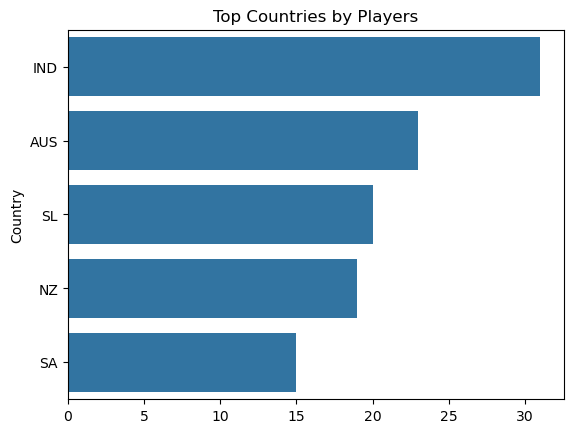

In [154]:
# top countries with highest players
top_countries = df['Country'].value_counts().head(5)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Countries by Players")
plt.show()

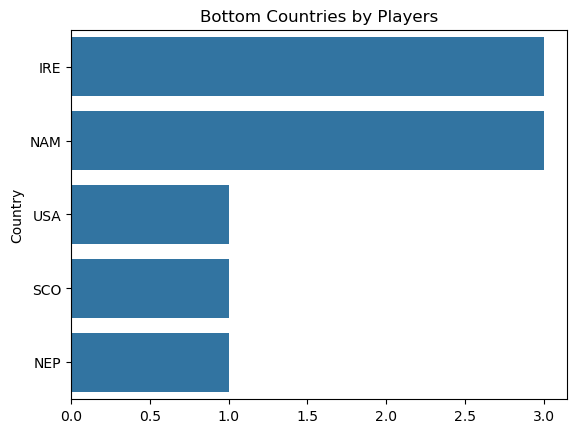

In [155]:
# Bottom countries with Least players
bottom_countries = df['Country'].value_counts().tail(5)
sns.barplot(x=bottom_countries.values, y=bottom_countries.index)
plt.title("Bottom Countries by Players")
plt.show()

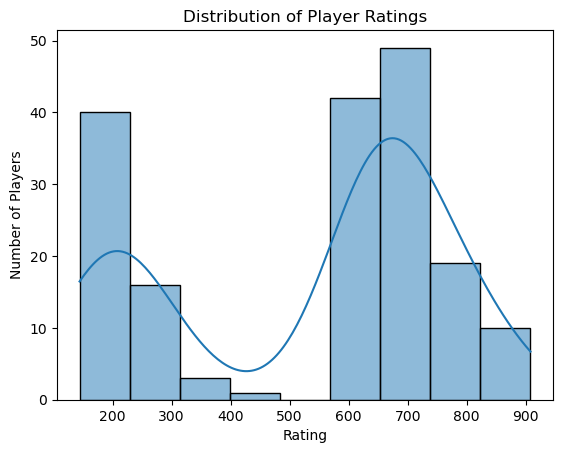

In [51]:
# rating distribution among the players using histplot
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df["Rating"], kde=True)
plt.title("Distribution of Player Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Players")
plt.show()

### Insights:
- The rating distribution shows a strong concentration between 600–750, indicating most players fall into a mid-to-high performance tier.
-  A smaller cluster around 200–300 suggests lower-performing categories or different player roles, indicating a non-uniform distribution.
-  The KDE curve provides a smooth estimate of the rating distribution. It highlights concentration zones more clearly than the histogram. In this case, the curve shows a higher peak around 650–750 and a smaller peak around 200–300, indicating a bimodal distribution of player ratings.

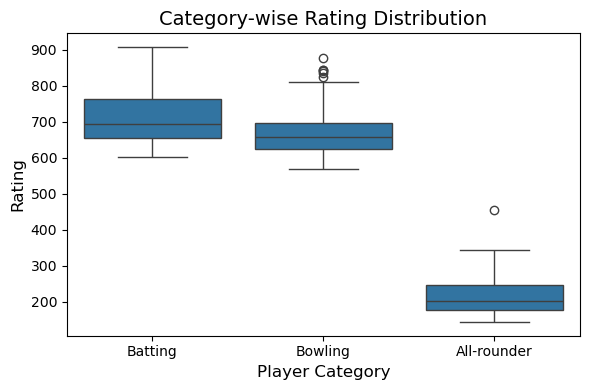

In [89]:
# category wise rating distribution
plt.figure(figsize=(6,4))

sns.boxplot(x="Category",y="Rating",data=df)
plt.title("Category-wise Rating Distribution", fontsize=14)
plt.xlabel("Player Category", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.tight_layout()
plt.show()

### Insights:
- Batting category shows the highest median ratings with a wide spread, indicating both strong top performers and variability in player performance across ranks.
- Bowling ratings are slightly lower than batting but display a consistent distribution, with a few high-value outliers indicating exceptional bowlers.
- All-rounders have significantly lower and clustered ratings, suggesting a different evaluation scale and more consistent but moderate performance levels and an outlier that shows a high performance player from the all rounder category

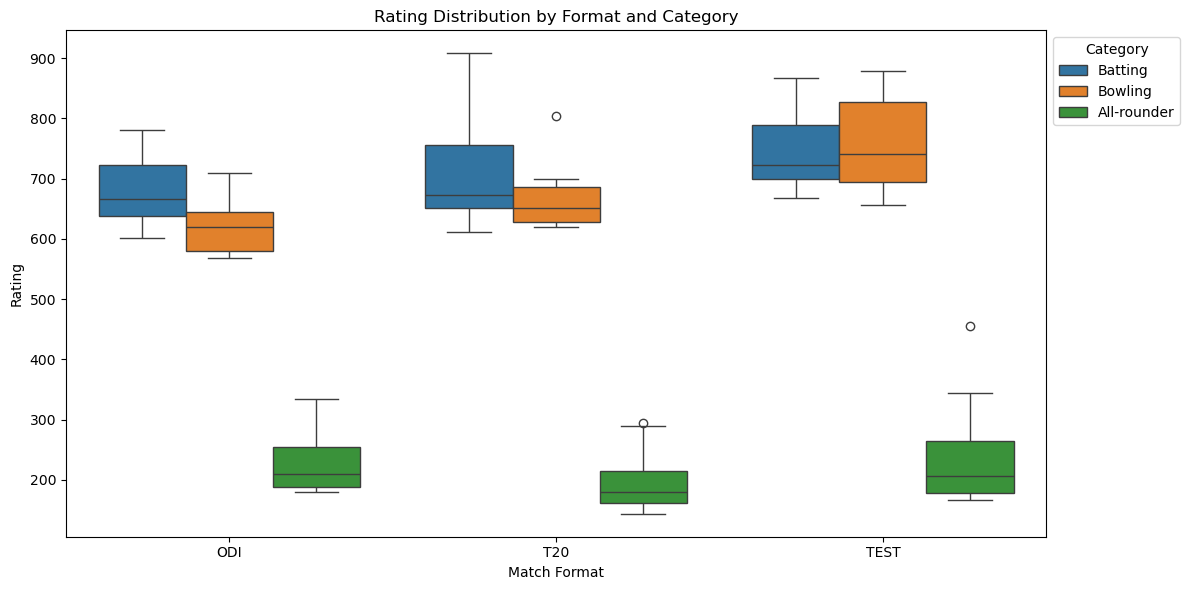

In [91]:
# format wise categorical rating using boxplot
plt.figure(figsize=(12,6))
sns.boxplot(
    x="Format",          # ODI, T20, Test
    y="Rating",
    hue="Category",      # Batting, Bowling, All-rounder
    data=df)
plt.title("Rating Distribution by Format and Category")
plt.xlabel("Match Format")
plt.ylabel("Rating")
plt.legend(title="Category", bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()

# Insights:
🟦1. **Test format shows highest performance levels**
- Test format consistently has the highest median ratings across both batting and bowling categories, indicating that players tend to achieve stronger performance metrics in longer-format cricket.

🟧2.**T20 format shows comparatively lower and tighter distributions**
- T20 ratings are relatively lower and more tightly clustered, suggesting limited variation in player performance due to the shorter format and fewer opportunities to accumulate high scores.

🟩 3. **All-rounders remain lowest across all formats**
- All-rounders consistently have significantly lower ratings across ODI, T20, and Test formats, confirming that their evaluation is distributed across multiple skills, leading to a compressed rating scale.

In [108]:
# format wise avg rating in each category
avg_rating=df.groupby(["Format","Category"])["Rating"].mean().reset_index()
avg_rating.style.hide(axis="index")

Format,Category,Rating
ODI,All-rounder,226.600000
ODI,Batting,683.050000
ODI,Bowling,616.750000
T20,All-rounder,194.300000
T20,Batting,702.700000
T20,Bowling,661.050000
TEST,All-rounder,235.350000
TEST,Batting,744.150000
TEST,Bowling,755.800000


In [32]:
# format wise top 3 players in each category:
for fmt in df["Format"].unique():
    print(f"\n======================= {fmt} =======================")
    temp = (
        df[df["Format"] == fmt]
        .sort_values(["Category", "Rank"])
        .groupby("Category")
        .head(3)
        .reset_index(drop=True)
    )
    display(temp[["Category", "Rank", "Player", "Country", "Rating"]])


======================= ODI =======================


,Category,Rank,Player,Country,Rating
0,All-rounder,1,Azmatullah Omarzai,AFG,334
1,All-rounder,2,Sikandar Raza,ZIM,302
2,All-rounder,3,Mohammad Nabi,AFG,285
3,Batting,1,Rohit Sharma,IND,781
4,Batting,2,Virat Kohli,IND,773
5,Batting,3,Daryl Mitchell,NZ,766
6,Bowling,1,Rashid Khan,AFG,710
7,Bowling,2,Jofra Archer,ENG,670
8,Bowling,3,Kuldeep Yadav,IND,655



======================= T20 =======================


,Category,Rank,Player,Country,Rating
0,All-rounder,1,Saim Ayub,PAK,295
1,All-rounder,2,Sikandar Raza,ZIM,289
2,All-rounder,3,Roston Chase,WI,252
3,Batting,1,Abhishek Sharma,IND,908
4,Batting,2,Philip Salt,ENG,849
5,Batting,3,Tilak Varma,IND,805
6,Bowling,1,Varun Chakaravarthy,IND,804
7,Bowling,2,Jacob Duffy,NZ,699
8,Bowling,3,Rashid Khan,AFG,694



======================= TEST =======================


,Category,Rank,Player,Country,Rating
0,All-rounder,1,Ravindra Jadeja,IND,455
1,All-rounder,2,Marco Jansen,SA,344
2,All-rounder,3,Ben Stokes,ENG,316
3,Batting,1,Joe Root,ENG,867
4,Batting,2,Harry Brook,ENG,846
5,Batting,3,Kane Williamson,NZ,822
6,Bowling,1,Jasprit Bumrah,IND,879
7,Bowling,2,Mitchell Starc,AUS,843
8,Bowling,3,Noman Ali,PAK,843


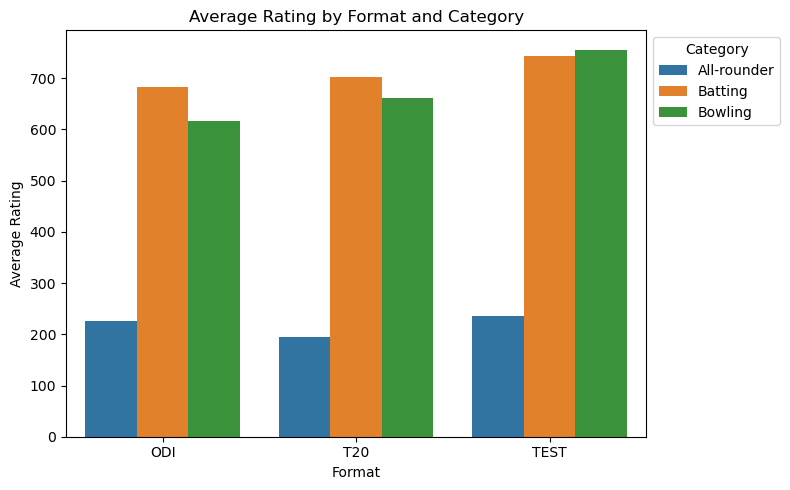

In [34]:
# Avg rating in each Format in 3 Categories.
plt.figure(figsize=(8,5))
sns.barplot(x='Format',y='Rating',hue='Category',data=avg_rating)
plt.title("Average Rating by Format and Category")
plt.xlabel("Format")
plt.ylabel("Average Rating");
plt.legend(title="Category", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insights:
1. **Test format shows highest overall performance**
    - Test cricket has the highest average ratings across all categories, indicating that players perform better or accumulate higher ratings in longer formats.

2. **Batting consistently leads across all formats**
    - Batting has the highest average rating in ODI, T20, and Test, showing that batting contributes the most to overall player ratings.

3. All-rounders have significantly lower ratings
    - All-rounders consistently show much lower average ratings compared to batting and bowling, confirming a different evaluation scale for multi-skill players.

In [22]:
# minimum and maximum rank
df["Rank"].min(), df["Rank"].max()

(1, 20)

In [24]:
# minimum and maximum Rating
df["Rating"].min(), df["Rating"].max()

(144, 908)

In [25]:
# unique ranks count
df["Rank"].nunique()

20

In [26]:
# count of each rank
df["Rank"].value_counts().sort_index()

Rank
1     9
2     9
3     9
4     9
5     9
6     9
7     9
8     9
9     9
10    9
11    9
12    9
13    9
14    9
15    9
16    9
17    9
18    9
19    9
20    9
Name: count, dtype: int64

In [123]:
# correlation betwen rank and rating
df[["Rank","Rating"]].corr()

,Rank,Rating
Rank,1.000000,-0.224557
Rating,-0.224557,1.000000


- There is a weak negative correlation (-0.22) between rank and rating. While ratings tend to decrease as rank increases, the relationship is not very strong due to variation across player categories with different rating scales.”

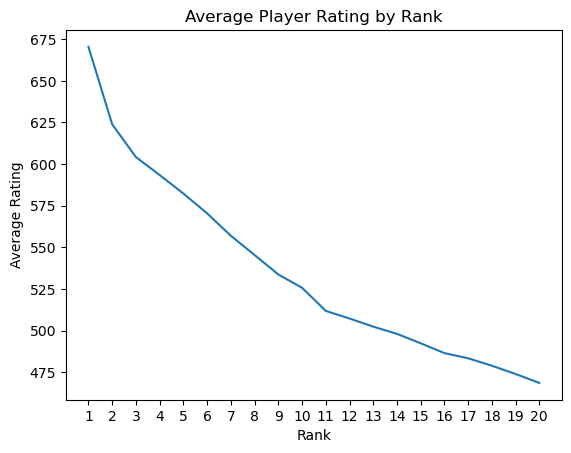

In [158]:
# rank vs rating
avg_rank_rating = df.groupby("Rank")["Rating"].mean()

plt.plot(avg_rank_rating.index, avg_rank_rating.values)
plt.xlabel("Rank")
plt.ylabel("Average Rating")
plt.title("Average Player Rating by Rank")
plt.xticks(range(1,21))
plt.show()

# Insights :
- Average rating steadily declines as the numerical rank moves from 1 toward 20, indicating a strong inverse relationship between rank position and performance score.
- The decline is sharper between Rank 1 and Rank 5 compared to later ranks, indicating a noticeable performance gap among the top-ranked players.
- After approximately Rank 10, the decline becomes more gradual, suggesting tighter competition and smaller rating differences among mid-to-lower  ranked players.

In [159]:
# country wise avg rating and their player count
country_stats = df.groupby("Country").agg(Average_Rating=("Rating", "mean"),
                Player_Count=("Player", "count")).sort_values(by="Average_Rating", ascending=False)
print(country_stats)

         Average_Rating  Player_Count
Country                              
SL           597.650000            20
AUS          588.913043            23
USA          582.000000             1
PAK          580.307692            13
IND          568.322581            31
ENG          555.500000            14
SA           547.133333            15
BAN          539.000000             7
NZ           519.315789            19
IRE          506.666667             3
AFG          458.500000            12
WI           418.583333            12
ZIM          410.000000             5
NAM          334.666667             3
SCO          228.000000             1
NEP          202.000000             1


In [28]:
# country wise avg rating
df.groupby("Country")["Rating"].mean().sort_values(ascending=False)

Country
SL     597.650000
AUS    588.913043
USA    582.000000
PAK    580.307692
IND    568.322581
ENG    555.500000
SA     547.133333
BAN    539.000000
NZ     519.315789
IRE    506.666667
AFG    458.500000
WI     418.583333
ZIM    410.000000
NAM    334.666667
SCO    228.000000
NEP    202.000000
Name: Rating, dtype: float64

In [99]:
# Country wise average rating in different categories
pivot_df = df.pivot_table(
    index="Country",
    columns="Category",
    values="Rating",
    aggfunc="mean"
    )
Pivot_df = pivot_df.round(2)
Pivot_df

Category,All-rounder,Batting,Bowling
Country,,,
AFG,241.17,676.00,675.67
AUS,210.33,722.29,722.70
BAN,286.00,631.00,642.50
ENG,222.80,801.20,664.25
IND,221.56,742.00,678.36
IRE,187.00,666.50,NaN
NAM,179.50,NaN,645.00
NEP,202.00,NaN,NaN
NZ,199.71,709.88,697.50


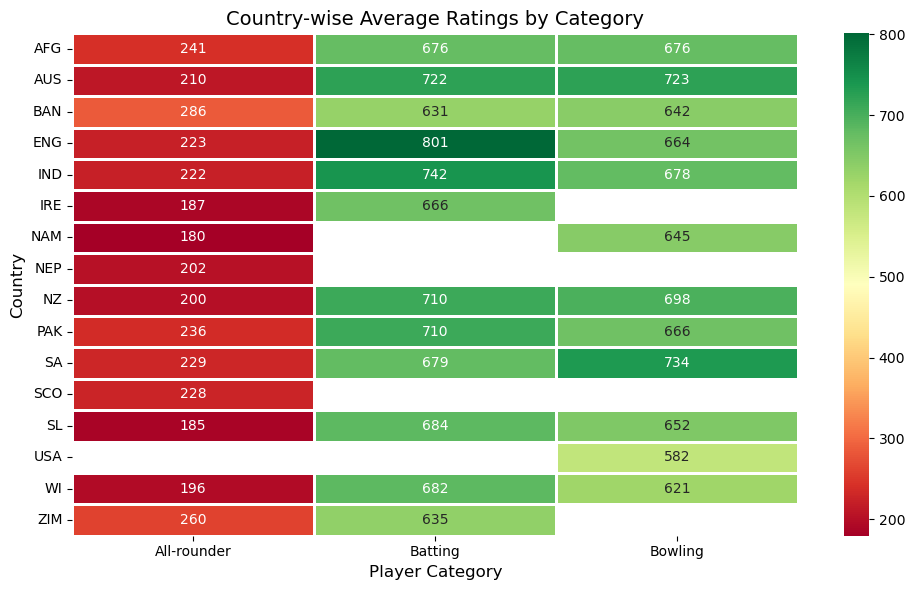

In [106]:
# Plot heatmap for above created pivot table
plt.figure(figsize=(10,6))
sns.heatmap(
    Pivot_df,
    annot=True,          # show values
    fmt=".0f",           # remove scientific notation
    cmap="RdYlGn",     # color theme
    linewidths=1       # grid lines for clarity
)

# Titles and labels
plt.title("Country-wise Average Ratings by Category", fontsize=14)
plt.xlabel("Player Category", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.tight_layout()
plt.show()

### Insights:
1. **England leads in batting performance**
   - England has the highest batting rating (~801), clearly outperforming all other countries in batting.

2. **South Africa dominates bowling**
   - South Africa records the highest bowling rating (~734), making it the strongest bowling team.

3. **Australia, India, and New Zealand show balanced strength**
   - These countries maintain consistently high ratings in both batting (~700+) and bowling (~670–720), showing consistency among all the formats in  all 3 categories indicating well-rounded team performance.

4. **All-rounders have significantly lower ratings across all countries**
    - All-rounder ratings remain in a much lower range (~180–280), confirming a different evaluation scale compared to batting and bowling.

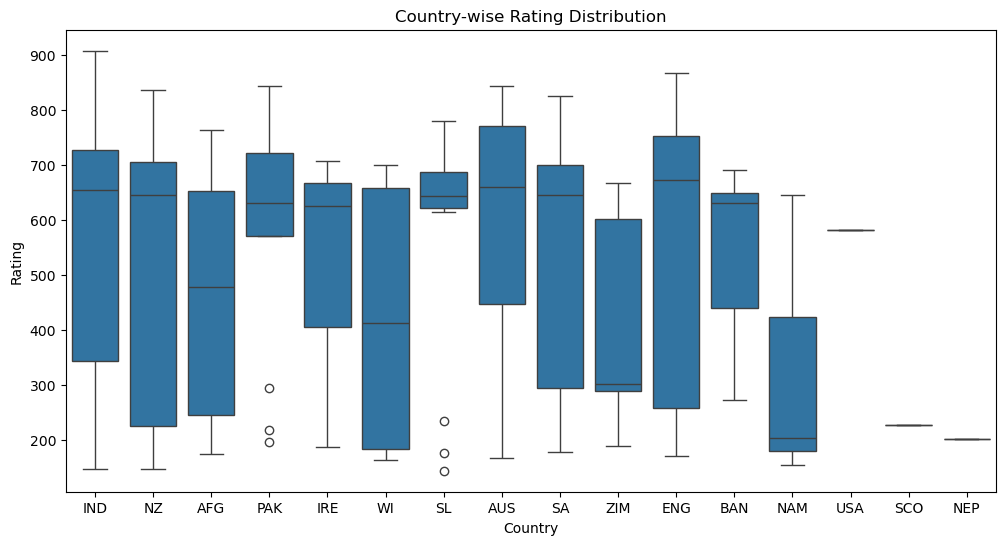

In [177]:
# country wise rating analysis using boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x="Country", y="Rating", data=df)
plt.title("Country-wise Rating Distribution")
plt.xlabel("Country")
plt.ylabel("Rating")
plt.xticks(rotation=0)
plt.show()

# Insights :
- Countries like AUS, ENG, IND, SA, and NZ have higher median ratings (around 630–670+).This indicates consistent high-level performance and strong competitive depth within these teams.
- Countries such as IND, ENG, NZ, and WI show wider rating spreads (large IQR), suggesting a mix of elite and mid-tier players.
  - In contrast, nations like NEP, SCO, and USA show narrow distributions, indicating limited variation and smaller talent pools.
- Countries like PAK and SL display lower-end outliers, meaning a few players have significantly lower ratings compared to the country’s core group.This reflects uneven performance distribution within those teams.

Category  All-rounder  Batting  Bowling
Format                                 
ODI            226.60   683.05   616.75
T20            194.30   702.70   661.05
TEST           235.35   744.15   755.80


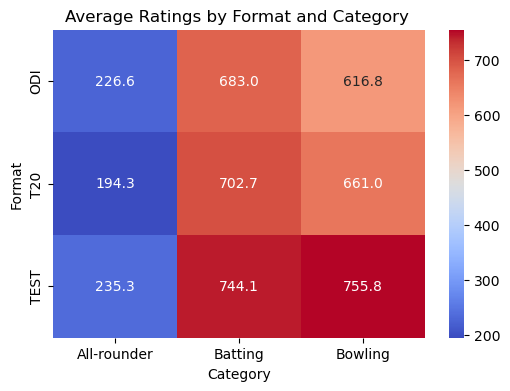

In [122]:
pivot = avg_rating.pivot(index='Format', columns='Category', values='Rating')
print(pivot)
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Average Ratings by Format and Category ")
plt.show()

### Insights:
- Test format enables higher performance in all categories due to longer gameplay.
- Batting remains consistently strong across formats.Bowling shows significant improvement in Test compared to shorter formats.
- All rounder category maintains low ratings across all the formats.

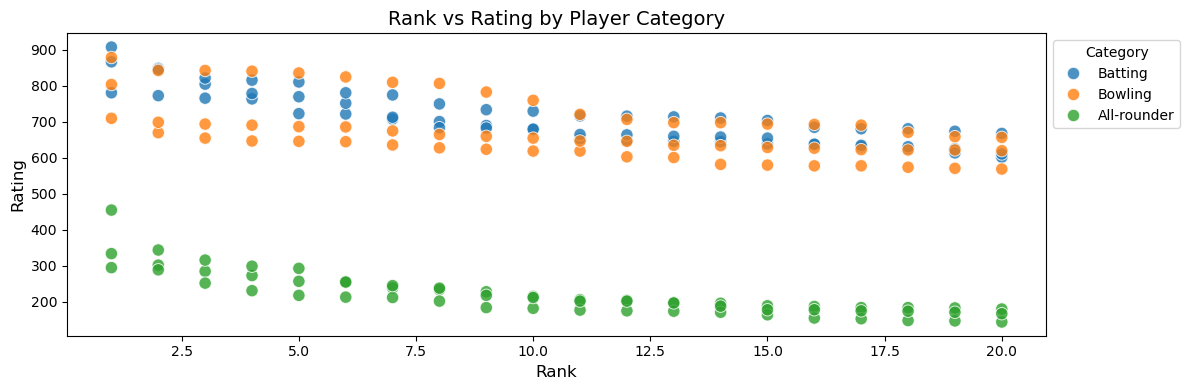

In [114]:
# Rank vs category by ratings using scatterplot
plt.figure(figsize=(12,4))
sns.scatterplot(x="Rank", y="Rating", hue="Category", data=df,
                s=80,              # bigger points
                alpha=0.8         # slight transparency
               )
plt.title("Rank vs Rating by Player Category", fontsize=14)
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Rating", fontsize=12)
# Move legend outside
plt.legend(title="Category", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout() # automatically adjusts spacings bw elements in the plot
plt.show()

### Insights:
1. **Strong inverse relationship between rank and rating**
    - As rank increases (moves from 1 to 20), ratings consistently decrease across all categories, confirming a clear negative correlation between rank and performance.

2. **Batting and bowling operate in a higher performance band**
    - Batting and bowling players maintain high rating ranges (~600–900), while all-rounders are clustered much lower (140–350), indicating different rating scales across roles.